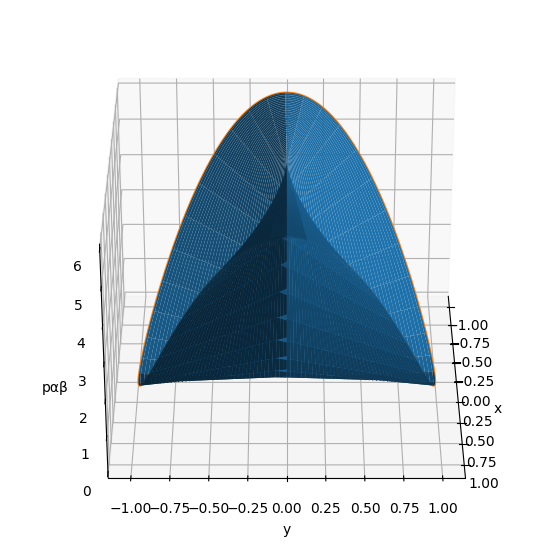

In [1]:
import numpy as np
import plotly.graph_objects as go

V = 1.0
R = 1.0

theta = np.linspace(0, 2*np.pi, 300)

# Equal positive + negative sequence
va = 2 * V * np.cos(theta)
vb = -V * np.cos(theta)
vc = -V * np.cos(theta)

# Clarke transform
T = np.sqrt(2/3) * np.array([
    [1.0, -0.5, -0.5],
    [0.0, np.sqrt(3)/2, -np.sqrt(3)/2],
    [1/np.sqrt(2), 1/np.sqrt(2), 1/np.sqrt(2)]
])

vabc = np.vstack([va, vb, vc]).T
vab0 = vabc @ T.T

v_alpha = vab0[:, 0]
v_beta = vab0[:, 1]

# Resistive normalization
i_alpha = v_alpha / R
i_beta = v_beta / R

p_ab = v_alpha * i_alpha + v_beta * i_beta

# Surface construction
r = np.linspace(0, 1, 80)
TH, RR = np.meshgrid(theta, r)

X = RR * np.cos(TH)
Y = RR * np.sin(TH)
Z = np.tile(p_ab, (len(r), 1))

fig = go.Figure()
fig.add_surface(
    x=X,
    y=Y,
    z=Z,
    colorscale='Viridis',
    opacity=0.9,
    showscale=True,
)
fig.add_scatter3d(
    x=np.cos(theta),
    y=np.sin(theta),
    z=p_ab,
    mode='lines',
    line=dict(color='black', width=6),
    name='rim',
)

fig.update_layout(
    width=800,
    height=800,
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='pαβ',
        aspectmode='cube',
        camera=dict(eye=dict(x=1.6, y=1.6, z=1.0)),
    ),
    margin=dict(l=0, r=0, t=40, b=0),
)

fig

